Training Data Shape: (112800, 785)
Testing Data Shape: (18800, 785)
Images Preprocessed Successfully!
Epoch 1/5
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - accuracy: 0.7602 - loss: 0.7846 - val_accuracy: 0.8232 - val_loss: 0.5166
Epoch 2/5
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.8511 - loss: 0.4375 - val_accuracy: 0.8570 - val_loss: 0.4076
Epoch 3/5
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 46s 32ms/step - accuracy: 0.8685 - loss: 0.3739 - val_accuracy: 0.8557 - val_loss: 0.4005
Epoch 4/5
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 87s 36ms/step - accuracy: 0.8809 - loss: 0.3338 - val_accuracy: 0.8626 - val_loss: 0.3858
Epoch 5/5
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.8894 - loss: 0.3035 - val_accuracy: 0.8706 - val_loss: 0.3694
588/588 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8694 - loss: 0.3899
Test Accuracy: 0.8693616986274719
Mapping Loaded Successfully!
Predicted Character: g
Actual Character: g


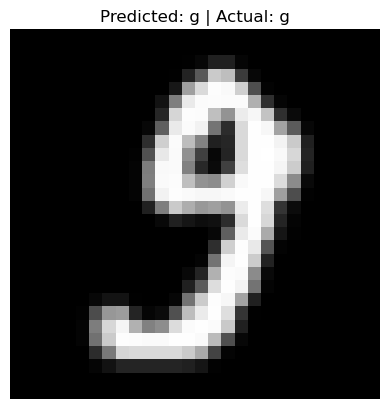

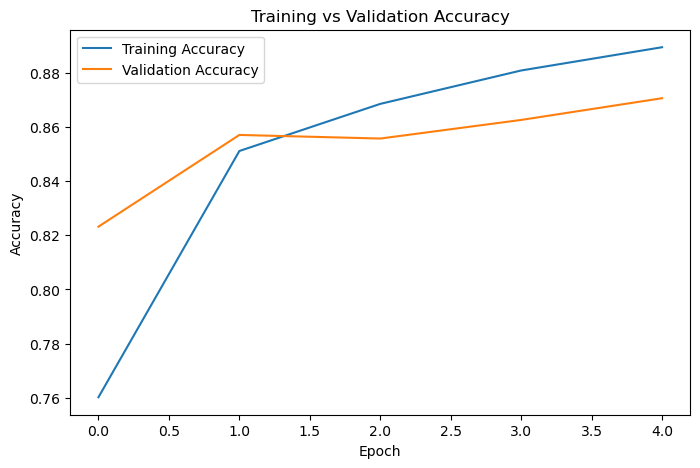

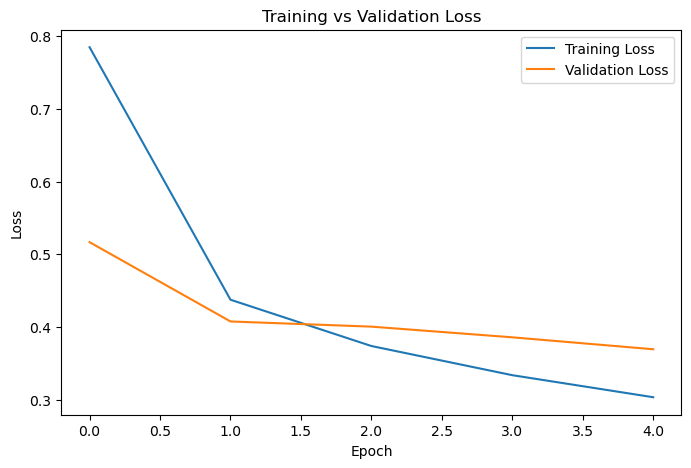

In [10]:
# Handwritten Character Recognition using CNN (EMNIST Balanced)

# Import Libraries
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

# Load EMNIST Balanced Dataset
train_data = pd.read_csv("emnist-balanced-train.csv", header=None)
test_data = pd.read_csv("emnist-balanced-test.csv", header=None)

print("Training Data Shape:", train_data.shape)
print("Testing Data Shape:", test_data.shape)
# Separate Labels and Images
# Separate Labels and Images
y_train = train_data.iloc[:, 0].values
x_train = train_data.iloc[:, 1:].values

y_test = test_data.iloc[:, 0].values
x_test = test_data.iloc[:, 1:].values

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28)
x_test = x_test.reshape(-1, 28, 28)

# Rotate and Flip Images
x_train = np.array([np.fliplr(np.rot90(img, k=3)) for img in x_train])
x_test = np.array([np.fliplr(np.rot90(img, k=3)) for img in x_test])

# Add Channel Dimension
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Images Preprocessed Successfully!")

from tensorflow.keras.layers import Input

model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(47, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=64
)
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

# Load EMNIST Mapping File
mapping = {}

with open("emnist-balanced-mapping.txt", "r") as file:
    for line in file:
        index, ascii_code = line.strip().split()
        mapping[int(index)] = chr(int(ascii_code))

print("Mapping Loaded Successfully!")
# Predict First Test Image
sample = x_test[0:1]

prediction = model.predict(sample, verbose=0)

predicted_class = np.argmax(prediction)
actual_class = y_test[0]

predicted_character = mapping[predicted_class]
actual_character = mapping[actual_class]

print("Predicted Character:", predicted_character)
print("Actual Character:", actual_character)

plt.imshow(sample[0].reshape(28, 28), cmap="gray")
plt.title(f"Predicted: {predicted_character} | Actual: {actual_character}")
plt.axis("off")
plt.show()

# Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()